# 07 - Meta-Learners


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import warnings

from fklearn.causal.validation.curves import relative_cumulative_gain_curve
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve


from cycler import cycler # for custom color cycles

warnings.filterwarnings("ignore")

color=['0.0', '0.4', '0.8']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)

## Meta-Learners for Discrete Treatments

In [2]:
pd.set_option('display.max_columns', 8)

In [3]:
import pandas as pd
import numpy as np

data_biased = pd.read_csv("./data/email_obs_data.csv") # biased observational data
data_rnd = pd.read_csv("./data/email_rnd_data.csv")    # unbiased RCT data

print(len(data_biased), len(data_rnd))
data_rnd.head()

300000 10000


,mkt_email,next_mnth_pv,age,tenure,...,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,...,1,0,0,2
1,0,29.67,36.0,1.0,...,1,0,2,2
2,0,11.73,64.0,0.0,...,0,1,0,1
3,0,41.41,74.0,0.0,...,0,4,1,0
4,0,447.89,59.0,0.0,...,1,1,2,1


In [4]:
y = "next_mnth_pv" # outcome variable
T = "mkt_email"    # treatment variable
X = list(data_rnd.drop(columns=[y, T]).columns) # covariates

train, test = data_biased, data_rnd # train on biased data, test on RCT data

 ### T-Learner

Text(0.5, 1.0, 'T-Learner with CatBoost')

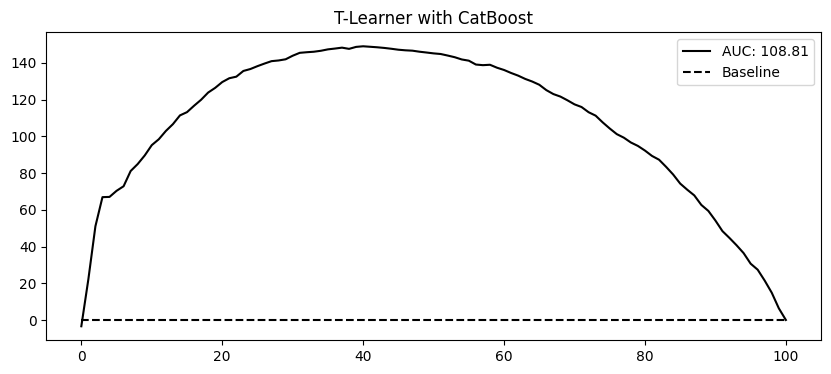

In [5]:
# Out of curiosity, use CatBoost as the base learner

# Check if CatBoost is installed, and if not install it using uv if not
try:
    import catboost
except ImportError:
    !uv add catboost

from catboost import CatBoostRegressor

np.random.seed(123)

m0 = CatBoostRegressor(verbose=0)
m1 = CatBoostRegressor(verbose=0)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y]);

t_learner_cate_test = test.assign(
    cate=m1.predict(test[X]) - m0.predict(test[X])
)

gain_curve_test = relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc_cb = area_under_the_relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc = auc_cb

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("T-Learner with CatBoost")

In [6]:
from lightgbm import LGBMRegressor

np.random.seed(123)

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y]);

In [7]:
t_learner_cate_test = test.assign(
    cate=m1.predict(test[X]) - m0.predict(test[X])
)

Text(0.5, 1.0, 'T-Learner with LightGBM')

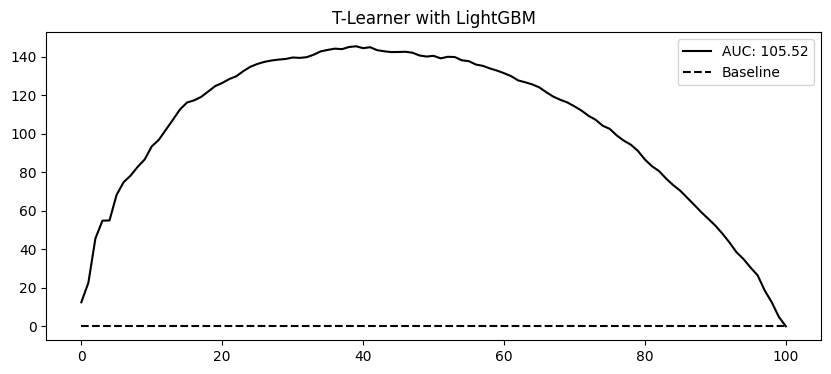

In [8]:
gain_curve_test = relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc_lgbm = area_under_the_relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc = auc_lgbm

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("T-Learner with LightGBM")

In [9]:
# TODO: Check this code carefully and understand how it works!
# This might be wrong!
# -------------------------------------------------------------------------
# Compute a permutation-based p-value for the relative cumulative gain AUC
#
# This function tests whether the predicted Conditional Average Treatment Effects
# (CATEs) rank units better than random with respect to their treatment response.
#
# How it works:
# 1. Computes the observed relative cumulative gain AUC using the predicted CATEs.

# 2. Repeatedly shuffles the treatment assignment in the dataset (permutation test)
#    and recomputes the AUC for each shuffle. This generates a null distribution of AUCs.
#    This makes the assumption that treatment assignment is random with respect to outcomes.

# 3. Calculates a two-sided p-value as the fraction of shuffled AUCs that are 
#    as extreme or more extreme than the observed AUC. 
#    This indicates how likely the observed AUC is under 
#    the null hypothesis of no treatment effect ranking ability.
#   
#
# Key points:
# - Works with continuous or binary outcomes.
# - The null hypothesis is that the predicted CATEs are no better than random
#   at ranking treatment effects.
# - A small p-value indicates that the model’s predicted CATEs significantly
#   improve treatment targeting compared to random assignment.
# -------------------------------------------------------------------------

def relative_gain_auc_permutation_test(df, treatment_col, outcome_col, pred_col='cate', n_permutations=1000, random_state=42):
    """
    Compute a p-value for the relative cumulative gain AUC using a permutation test.
    Works with continuous outcomes.
    """
    rng = np.random.default_rng(random_state) # for reproducibility
    
    # Compute observed AUC
    auc_obs = area_under_the_relative_cumulative_gain_curve(
        df=df,
        treatment=treatment_col,
        outcome=outcome_col,
        prediction=pred_col
    )
    
    # Permutation test
    auc_perm = np.zeros(n_permutations) # store permuted AUCs
    for i in range(n_permutations): # for each permutation
        # Shuffle the treatment column within a copy of the DataFrame
        df_perm = df.copy() # create a copy to avoid modifying original data
        df_perm[treatment_col] = rng.permutation(df[treatment_col].values) # shuffle treatment
        
        # Compute AUC on permuted data
        auc_perm[i] = area_under_the_relative_cumulative_gain_curve(
            df=df_perm,
            treatment=treatment_col,
            outcome=outcome_col,
            prediction=pred_col
        )
    
    # Two-sided p-value: proportion of permuted AUCs more extreme than observed
    p_value = np.mean(np.abs(auc_perm - 0.5) >= np.abs(auc_obs - 0.5))
    
    return auc_obs, p_value

# df, treatment_col, outcome_col, pred_col=

# --- Run test ---
auc_obs, p_value = relative_gain_auc_permutation_test(
    df = t_learner_cate_test, 
    treatment_col='mkt_email', 
    outcome_col='next_mnth_pv', 
    pred_col='cate',
    n_permutations=100  # smaller number for quick testing
)

print(f"Observed AUC: {auc_obs:.2f}, p-value: {p_value:.4f}")

Observed AUC: 105.52, p-value: 0.0000


In [10]:
# TODO: Test to assess if AUC from two models are significantly different

In [11]:
# Create random predictions for comparison
np.random.seed(99)
test_random = test.assign(
    cate=np.random.normal(0, 1, size=len(test))
)
auc_obs_rand, p_value_rand = relative_gain_auc_permutation_test(
    df = test_random,
    treatment_col='mkt_email', 
    outcome_col='next_mnth_pv', 
    pred_col='cate',
    n_permutations=100  # smaller number for quick testing
)

print(f"Random preds - Observed AUC: {auc_obs_rand:.4f}, p-value: {p_value_rand:.4f}")

Random preds - Observed AUC: 1.6551, p-value: 0.8100


Page 211
#### Consider a situation where you have lots of data for the untreated and very little data for the treated ... 

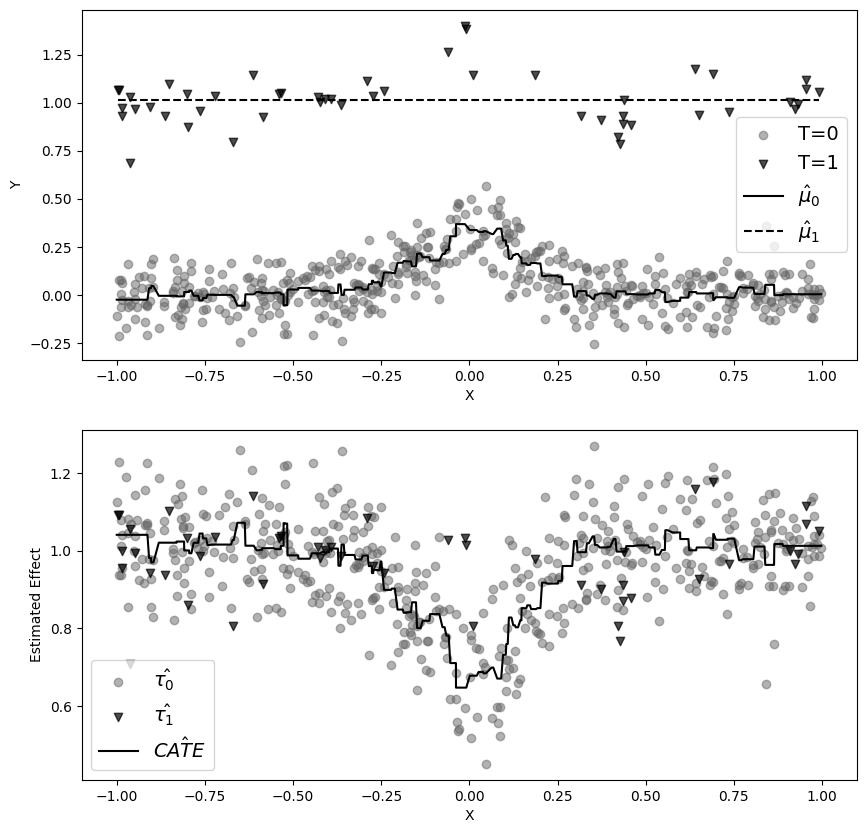

In [12]:
# Simulate a dataset with treatment and control groups, fits outcome models using LightGBM regressors,
# imputes treatment effects (tau_0 and tau_1) for each group, and visualizes both the observed outcomes and estimated effects.

# This is the first stage of the X-Learner for estimating Conditional Average Treatment Effects (CATE).


np.random.seed(123)

# Define a Gaussian kernel function to simulate nonlinear outcome behavior
def g_kernel(x, c=0, s=0.05): 
    return np.exp((-(x-c)**2)/s)

# Generate 500 control group samples
n0 = 500
x0 = np.random.uniform(-1, 1, n0) # # Covariate values for control group
y0 = np.random.normal(0.3*g_kernel(x0), 0.1, n0) # # Outcome for treated group with added treatment effect

# Generate 50 treated group samples (smaller sample size to simulate imbalance
n1 = 50
x1 = np.random.uniform(-1, 1, n1)
y1 = np.random.normal(0.3*g_kernel(x1), 0.1, n1)+1

# Combine control and treated data into a single DataFrame and sort by covariate 'x'
df = pd.concat([pd.DataFrame(dict(x=x0, y=y0, t=0)), pd.DataFrame(dict(x=x1, y=y1, t=1))]).sort_values(by="x")

# Initialize LightGBM regressors for outcome modeling in control and treated group

# m0 is the model for control outcomes
m0 = LGBMRegressor(min_child_samples=25, verbosity=-1)

# m1 is the model for treated outcomes
m1 = LGBMRegressor(min_child_samples=25, verbosity=-1)

# Fit outcome model for control group
m0.fit(x0.reshape(-1, 1), y0)

# Fit outcome model for treated group
m1.fit(x1.reshape(-1, 1), y1)

# Predict outcomes for control group using m0
m0_hat = m0.predict(df.query("t==0")[["x"]])

# Predict outcomes for treated group using m1
m1_hat = m1.predict(df.query("t==1")[["x"]])

# Create a figure with two subplots for visualizing outcomes and treatment effects
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Scatter plot of observed outcomes for control group
ax1.scatter(x0, y0, alpha=0.5, label="T=0", marker=marker[0], color=color[1])

# Scatter plot of observed outcomes for treated group
ax1.scatter(x1, y1, alpha=0.7, label="T=1", marker=marker[1], color=color[0])

# Plot predicted outcome curve for control group
ax1.plot(df.query("t==0")[["x"]], m0_hat, color="black", linestyle="solid",  label="$\hat{\mu}_0$")

# Plot predicted outcome curve for treated group
ax1.plot(df.query("t==1")[["x"]], m1_hat, color="black", linestyle="--",  label="$\hat{\mu}_1$")

# Label y-axis and x-axis for outcome plot
ax1.set_ylabel("Y")
ax1.set_xlabel("X")
ax1.legend(fontsize=14);

# Impute treatment effect for control group: predicted treated outcome - observed control outcome;
# m1 is the model for treated outcomes
tau_0 = m1.predict(df.query("t==0")[["x"]]) - df.query("t==0")["y"]

# Impute treatment effect for treated group: observed treated outcome - predicted control outcome
# m0 is the model for control outcomes
tau_1 = df.query("t==1")["y"] - m0.predict(df.query("t==1")[["x"]])

# Scatter plot of imputed treatment effects
ax2.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, marker=marker[0], color=color[1])
ax2.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.7, marker=marker[1], color=color[0])

# Plot estimated CATE curve
ax2.plot(df[["x"]], m1.predict(df[["x"]]) - m0.predict(df[["x"]]), label="$\hat{CATE}$",  color="black")

# Label y-axis and x-axis for treatment effect plot
ax2.set_ylabel("Estimated Effect")
ax2.set_xlabel("X")
ax2.legend(fontsize=14)


p. 212
### X-Learner

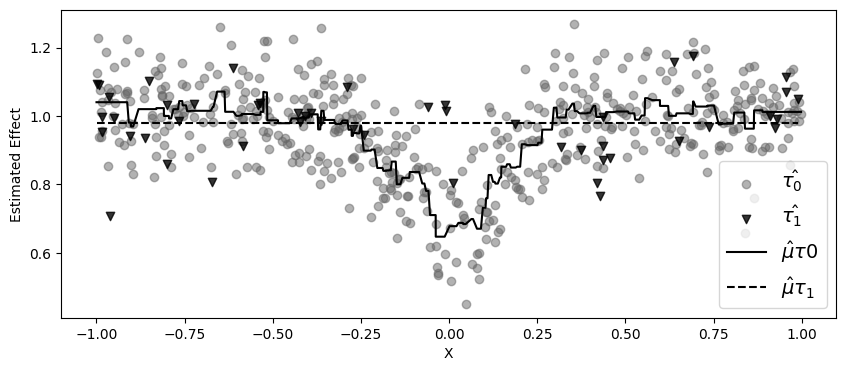

In [13]:
# This code implements the second stage of the X-Learner for estimating Conditional Average Treatment Effects (CATE).
# It trains two separate models (mu_tau0 and mu_tau1) to predict imputed treatment effects for control and treated groups, respectively.

# These models are trained using LightGBM regressors on the covariate 'x'.

# The predicted effects (mu_tau0_hat and mu_tau1_hat) are then visualized to assess how well the models capture treatment heterogeneity.

# This approach helps mitigate regularization bias by leveraging more abundant data and combining predictions using propensity scores in later steps.

# Import logistic regression model for propensity score estimation (used later in X-Learner
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(1) 

# Initialize LightGBM regressors for estimating treatment effects in control (t=0) and treated (t=1) groups
mu_tau0 = LGBMRegressor(min_child_samples=25, verbosity=-1)
mu_tau1 = LGBMRegressor(min_child_samples=25, verbosity=-1)


# Fit mu_tau0 on control group (t=0) to predict imputed treatment effects (tau_0);
# tau_0 represents the estimated treatment effect for control units, 
# calculated as the difference between predicted treated outcome and observed control outcome.
mu_tau0.fit(df.query("t==0")[["x"]], tau_0)

# Fit mu_tau1 on treated group (t=1) to predict imputed treatment effects (tau_1)
# tau_1 represents the estimated treatment effect for treated units, 
# calculated as the difference between observed treated outcome and predicted control outcome.
mu_tau1.fit(df.query("t==1")[["x"]], tau_1)

# Predict treatment effects for control group using trained mu_tau0 model
mu_tau0_hat = mu_tau0.predict(df.query("t==0")[["x"]])

# Predict treatment effects for treated group using trained mu_tau1 model
mu_tau1_hat = mu_tau1.predict(df.query("t==1")[["x"]])

plt.figure(figsize=(10, 4))

# Scatter plot of actual imputed treatment effects for control group
plt.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, marker=marker[0], color=color[1])

# Scatter plot of actual imputed treatment effects for treated group
plt.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.8, marker=marker[1], color=color[0])

# Plot predicted treatment effect curve for control group (solid line)
plt.plot(df.query("t==0")[["x"]], mu_tau0_hat, color="black", linestyle="solid", label="$\hat{\mu}\\tau 0$")

# Plot predicted treatment effect curve for treated group (dashed line)
plt.plot(df.query("t==1")[["x"]], mu_tau1_hat, color="black", linestyle="dashed", label="$\hat{\mu}\\tau_1$")

# Label the y-axis as "Estimated Effect"
plt.ylabel("Estimated Effect")

# Label the x-axis as "X" (covariate)
plt.xlabel("X")

# Display legend with font size 14
plt.legend(fontsize=14)


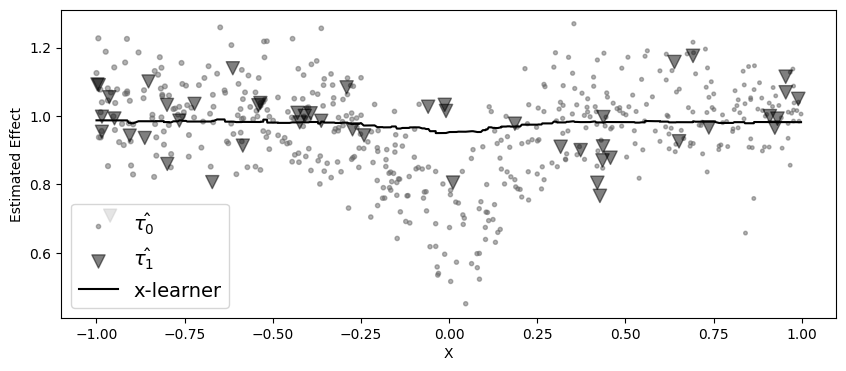

In [14]:
# Implements the final step of the X-Learner by combining imputed treatment effects (tau_0 and tau_1)
# using propensity score weights to estimate the Conditional Average Treatment Effect (CATE).
# Visualizes the weighted treatment effects and the final CATE curve.

# # Create a new figure for plotting the results
plt.figure(figsize=(10, 4))

# # Initialize logistic regression model to estimate propensity scores (probability of receiving treatment)
ps_model = LogisticRegression(penalty=None)

# Fit the propensity score model using covariate 'x' to predict treatment assignment 't'
ps_model.fit(df[["x"]], df["t"])

# Predict propensity scores (probability of being treated) for all units
ps = ps_model.predict_proba(df[["x"]])[:, 1]

# Combine imputed treatment effects using propensity scores to estimate CATE
# Gives more weight to the imputed effect from the group with more data
cate = ((1-ps)*mu_tau1.predict(df[["x"]]) +
        ps*mu_tau0.predict(df[["x"]]))

# Scatter plot of tau_0 (control group) with point size scaled by propensity score (higher = more weight)
plt.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, s=100*(ps[df["t"]==0]),   marker=marker[0], color=color[1])

# Scatter plot of tau_1 (treated group) with point size scaled by inverse propensity score (higher = more weight)
plt.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.5, s=100*(1-ps[df["t"]==1]), marker=marker[1], color=color[0])

# Plot the final CATE estimate from the X-Learner
plt.plot(df[["x"]], cate, label="x-learner", color="black")

# Label the y-axis as "Estimated Effect"
plt.ylabel("Estimated Effect")

# Label the x-axis as "X" (covariate)
plt.xlabel("X")
plt.legend(fontsize=14)

p. 214-216

Another thing you can try is the *domain adaptation learner*. 

It is the X-learner, but using the propensity score model to estimate  
  $\hat{\mu}_t(X)$ (the estimated potential outcome for a unit with covariates X) with weights set to   
    $1 / \hat{P}(T = t)$ (the estimated propensity score, which is the probability that a unit with certain characteristics (covariates) receives treatment level t).

(This means that units which are less likely to receive treatment t are given more weight during model training,  
helping correct for selection bias and improving the robustness of the treatment effect estimation.)

In [15]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

# propensity score model
ps_model = LogisticRegression(penalty=None)
ps_model.fit(train[X], train[T])


# first stage models
train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

np.random.seed(123)

m0.fit(train_t0[X], train_t0[y],
       sample_weight=1/ps_model.predict_proba(train_t0[X])[:, 0])

m1.fit(train_t1[X], train_t1[y],
       sample_weight=1/ps_model.predict_proba(train_t1[X])[:, 1]);


In [16]:
# second stage
tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor(verbosity=-1)
m_tau_1 = LGBMRegressor(verbosity=-1)

np.random.seed(123)

m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1);

In [17]:
# estimate the CATE
ps_test = ps_model.predict_proba(test[X])[:, 1]

x_cate_test = test.assign(
    cate=(ps_test*m_tau_0.predict(test[X]) +
          (1-ps_test)*m_tau_1.predict(test[X])
         )
)

Text(0.5, 1.0, 'X-Learner')

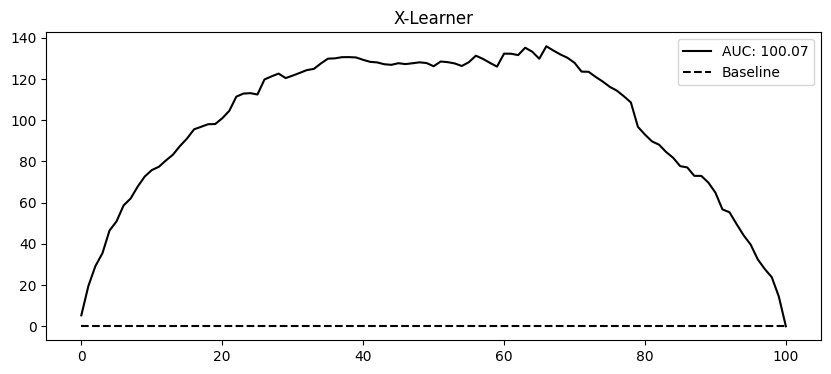

In [18]:
gain_curve_test = relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("X-Learner")

In [19]:
# Calculate p-value for X-Learner CATE estimates
auc_obs_x, p_value_x = relative_gain_auc_permutation_test(
    df = x_cate_test,
    treatment_col='mkt_email', 
    outcome_col='next_mnth_pv', 
    pred_col='cate',
    n_permutations=100,
    random_state=42
)

print(f"X-Learner - Observed AUC: {auc_obs_x:.2f}, p-value: {p_value_x:.4f}")

X-Learner - Observed AUC: 100.07, p-value: 0.0000


## Meta-Learners for Continuous Treatments


In [20]:
data_cont = pd.read_csv("./data/discount_data.csv")
data_cont.head()

,rest_id,day,month,weekday,...,is_nov,competitors_price,discounts,sales
0,0,2016-01-01,1,4,...,False,2.88,0,79.0
1,0,2016-01-02,1,5,...,False,2.64,0,57.0
2,0,2016-01-03,1,6,...,False,2.08,5,294.0
3,0,2016-01-04,1,0,...,False,3.37,15,676.5
4,0,2016-01-05,1,1,...,False,3.79,0,66.0


In [21]:
train = data_cont.query("day<'2018-01-01'")
test = data_cont.query("day>='2018-01-01'")

### S-Learner


In [22]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

np.random.seed(123)
s_learner = LGBMRegressor()
s_learner.fit(train[X+[T]], train[y]);

In [23]:
t_grid = pd.DataFrame(dict(key=1,
                           discounts=np.array([0, 10, 20, 30, 40])))

test_cf = (test
           .drop(columns=["discounts"])
           .assign(key=1)
           .merge(t_grid)
           # make predictions after expansion
           .assign(sales_hat = lambda d: s_learner.predict(d[X+[T]])))

test_cf.head(8)

,rest_id,day,month,weekday,...,sales,key,discounts,sales_hat
0,0,2018-01-01,1,0,...,251.5,1,0,67.957972
1,0,2018-01-01,1,0,...,251.5,1,10,444.245941
2,0,2018-01-01,1,0,...,251.5,1,20,793.045769
3,0,2018-01-01,1,0,...,251.5,1,30,1279.640793
4,0,2018-01-01,1,0,...,251.5,1,40,1512.630767
5,0,2018-01-02,1,1,...,541.0,1,0,65.672080
6,0,2018-01-02,1,1,...,541.0,1,10,495.669220
7,0,2018-01-02,1,1,...,541.0,1,20,1015.401471


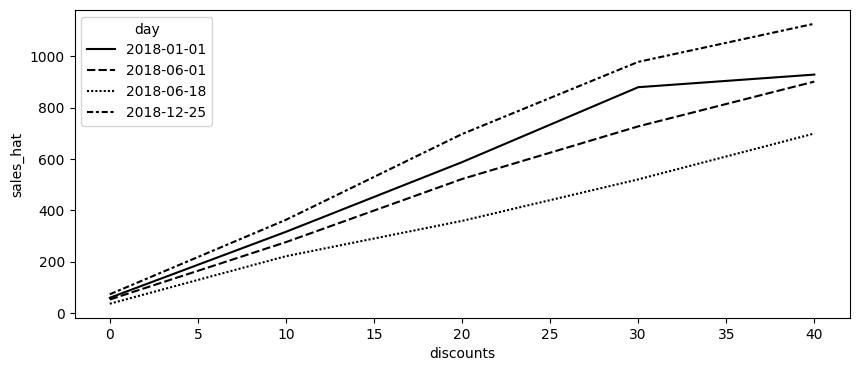

In [24]:
days = ["2018-12-25", "2018-01-01", "2018-06-01", "2018-06-18"]

plt.figure(figsize=(10, 4))
sns.lineplot(data=test_cf.query("day.isin(@days)").query("rest_id==2"),
             palette="gray",
             y="sales_hat",
             x="discounts",
             style="day");



In [25]:
from toolz import curry

@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1]/df[t].var()


cate = (test_cf
        .groupby(["rest_id", "day"])
        .apply(linear_effect(t="discounts", y="sales_hat"))
        .rename("cate"))

test_s_learner_pred = test.set_index(["rest_id", "day"]).join(cate)

test_s_learner_pred.head()

month  weekday  weekend  is_holiday  ...  \
rest_id day                                              ...   
0       2018-01-01      1        0    False        True  ...   
        2018-01-02      1        1    False       False  ...   
        2018-01-03      1        2    False       False  ...   
        2018-01-04      1        3    False       False  ...   
        2018-01-05      1        4    False       False  ...   

                    competitors_price  discounts  sales       cate  
rest_id day                                                         
0       2018-01-01               4.92          5  251.5  37.247404  
        2018-01-02               3.06         10  541.0  40.269854  
        2018-01-03               4.61         10  431.0  37.412988  
        2018-01-04               4.84         20  760.0  38.436815  
        2018-01-05               6.29          0   78.0  31.428603  

[5 rows x 10 columns]

Text(0.5, 1.0, 'S-Learner')

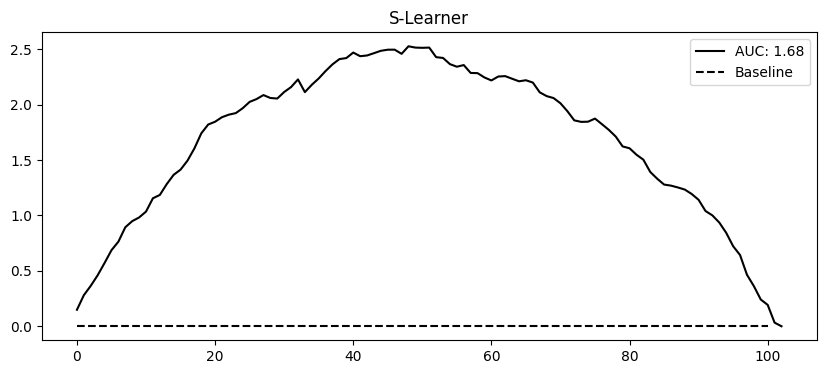

In [26]:
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve
from fklearn.causal.validation.curves import relative_cumulative_gain_curve

gain_curve_test = relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("S-Learner")


Text(0.5, 1.0, '500 Simulations')

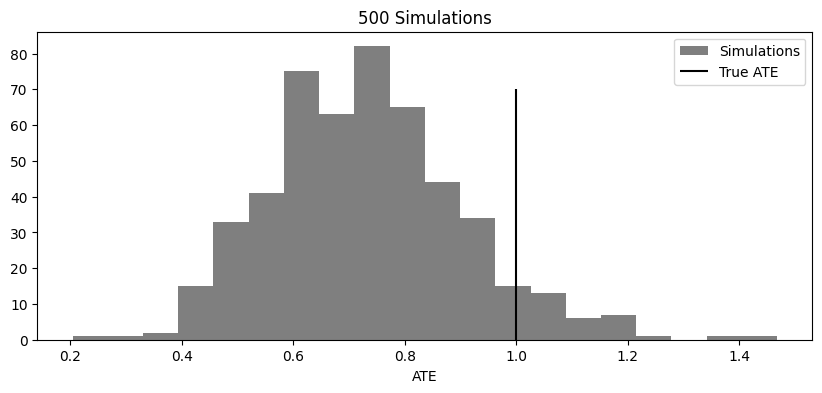

In [27]:
np.random.seed(123)

def sim_s_learner_ate():
    n = 10000
    nx = 20
    
    X = np.random.normal(0, 1, (n, nx))
    coefs_y = np.random.uniform(-1, 1, nx)
    coefs_t = np.random.uniform(-0.5, 0.5, nx)
    
    ps = 1/(1+np.exp(-(X.dot(coefs_t))))
    t = np.random.binomial(1, ps)
    te = 1
    
    y = np.random.normal(t*te + X.dot(coefs_y), 1)
    
    s_learner = LGBMRegressor(max_depth=5, n_jobs=4)
    s_learner.fit(np.concatenate([X, t.reshape(-1, 1)], axis=1), y);
    
    ate_hat = (s_learner.predict(np.concatenate([X, np.ones((n, 1))], axis=1))
               - s_learner.predict(np.concatenate([X, np.zeros((n, 1))], axis=1))).mean()
    
    return ate_hat
    
    
ates = [sim_s_learner_ate() for _ in range(500)]

plt.figure(figsize=(10, 4))
plt.hist(ates, alpha=0.5, bins=20, label="Simulations")
plt.vlines(1, 0, 70, label="True ATE")
plt.legend()
plt.xlabel("ATE")
plt.title("500 Simulations")

### Double/Debiased Machine Learning


In [28]:
from sklearn.model_selection import cross_val_predict

X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

debias_m = LGBMRegressor()
denoise_m = LGBMRegressor()

t_res =  train[T] - cross_val_predict(debias_m,train[X],train[T],cv=5)
y_res =  train[y] - cross_val_predict(denoise_m,train[X],train[y],cv=5)

In [29]:
import statsmodels.api as sm

sm.OLS(y_res, t_res).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
discounts,31.4634,0.151,209.017,0.000,31.168,31.759


#### Double-ML for CATE Estimation


In [30]:
y_star = y_res/t_res
w = t_res**2

cate_model = LGBMRegressor().fit(train[X], y_star, sample_weight=w)

test_r_learner_pred = test.assign(cate = cate_model.predict(test[X]))

Text(0.5, 1.0, 'R-Learner')

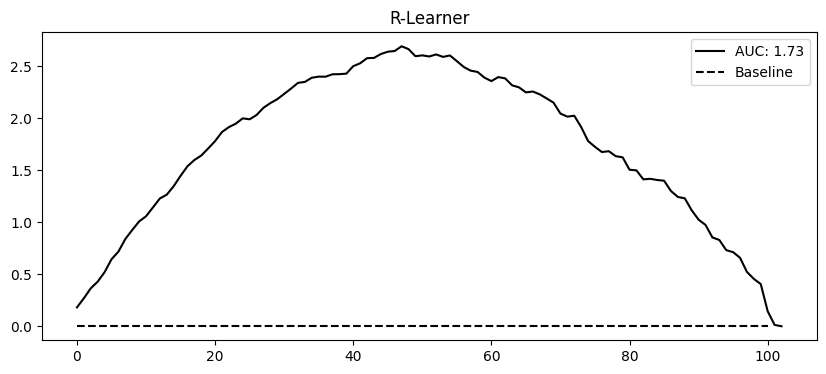

In [31]:
gain_curve_test = relative_cumulative_gain_curve(test_r_learner_pred, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_r_learner_pred, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("R-Learner")

#### Visual Intuition for Double-ML


In [32]:
np.random.seed(123)
n = 5000

x_h = np.random.randint(1, 4, n)
x_c = np.random.uniform(-1, 1, n)

t = np.random.normal(10 + 1*x_c + 3*x_c**2 + x_c**3, 0.3)
y = np.random.normal(t + x_h*t - 5*x_c - x_c**2 - x_c**3, 0.3)

df_sim = pd.DataFrame(dict(x_h=x_h, x_c=x_c, t=t, y=y))

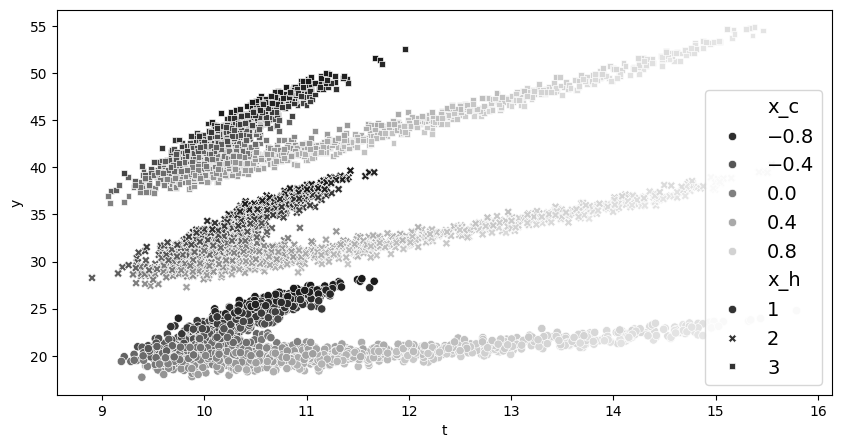

In [33]:
import matplotlib

plt.figure(figsize=(10, 5))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["0.1","0.5","0.9"])

sns.scatterplot(data=df_sim, y="y", x="t", hue="x_c", style="x_h", palette=cmap);
plt.legend(fontsize=14)

In [34]:
debias_m = LGBMRegressor(max_depth=3)
denoise_m = LGBMRegressor(max_depth=3)

t_res = cross_val_predict(debias_m, df_sim[["x_c"]], df_sim["t"],
                          cv=10)

y_res = cross_val_predict(denoise_m, df_sim[["x_c", "x_h"]],df_sim["y"],
                          cv=10)

df_res = df_sim.assign(
    t_res =  df_sim["t"] - t_res,
    y_res =  df_sim["y"] - y_res
)

In [35]:
import statsmodels.formula.api as smf

smf.ols("y_res~t_res", data=df_res).fit().params["t_res"]

3.0452301460062925

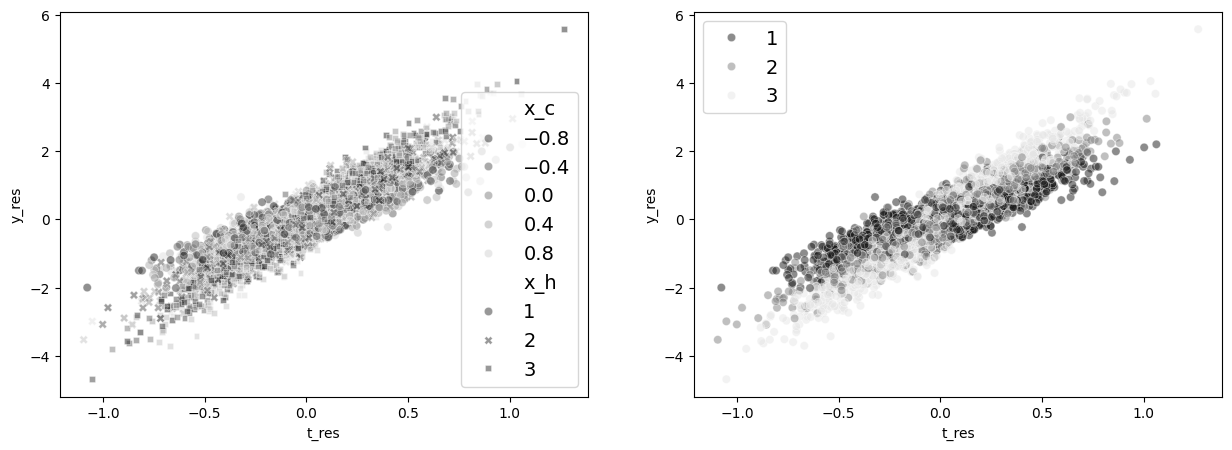

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1 = sns.scatterplot(data=df_res, y="y_res", x="t_res", hue="x_c", style="x_h", alpha=0.5, ax=ax1, palette=cmap)

h,l = ax1.get_legend_handles_labels()
ax1.legend(fontsize=14)

sns.scatterplot(data=df_res, y="y_res", x="t_res", hue="x_h", ax=ax2, alpha=0.5, palette=cmap)
ax2.legend(fontsize=14)


In [37]:
df_star = df_res.assign(
    y_star = df_res["y_res"]/df_res["t_res"],
    weight = df_res["t_res"]**2,
)

for x in range(1, 4):
    cate = np.average(df_star.query(f"x_h=={x}")["y_star"],
                      weights=df_star.query(f"x_h=={x}")["weight"])
    
    print(f"CATE x_h={x}", cate)

CATE x_h=1 2.019759619990067
CATE x_h=2 2.974967932350952
CATE x_h=3 3.9962382855476957


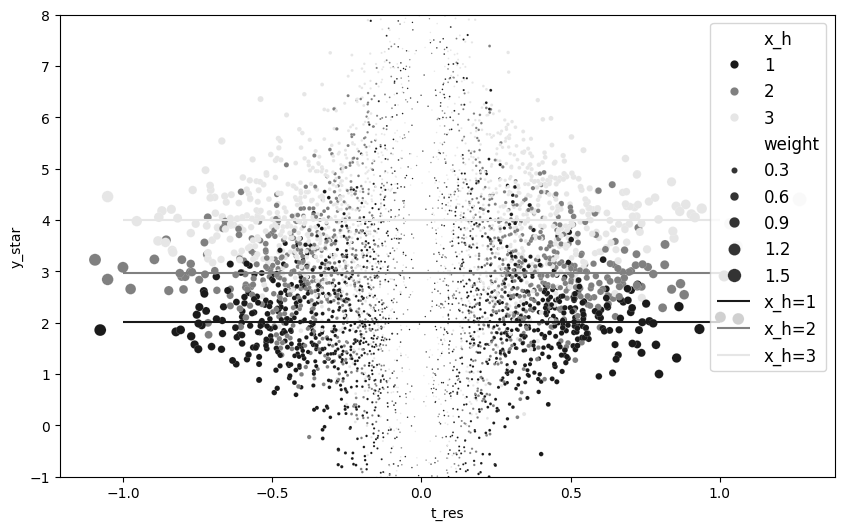

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_star, palette=cmap,
                y="y_star", x="t_res", hue="x_h", size="weight", sizes=(1, 100)), 

plt.hlines(np.average(df_star.query("x_h==1")["y_star"], weights=df_star.query("x_h==1")["weight"]),
           -1, 1, label="x_h=1", color="0.1")

plt.hlines(np.average(df_star.query("x_h==2")["y_star"], weights=df_star.query("x_h==2")["weight"]),
           -1, 1, label="x_h=2", color="0.5")

plt.hlines(np.average(df_star.query("x_h==3")["y_star"], weights=df_star.query("x_h==3")["weight"]),
           -1, 1, label="x_h=3", color="0.9")

plt.ylim(-1, 8)

plt.legend(fontsize=12)



## Key Ideas
 
